In [24]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
from sklearn.datasets import make_circles

<Axes: >

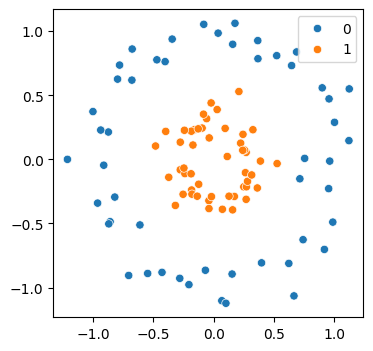

In [3]:
X,y = make_circles(n_samples = 100,noise = .1,factor = 0.3)
plt.figure(figsize=(4,4))
sns.scatterplot(x=X[:,0],y=X[:,1],hue = y)

In [4]:
print(X)

[[-8.73592862e-01  2.13443448e-01]
 [-5.76534066e-02  3.17769444e-01]
 [ 9.58915990e-01  4.72117836e-01]
 [-1.23526327e-01 -1.94112711e-01]
 [ 1.72587794e-01 -2.89363093e-01]
 [-5.47184435e-01 -8.90354862e-01]
 [ 7.43115040e-01 -6.26840752e-01]
 [ 2.24875394e-01  1.26336573e-01]
 [ 1.00435192e+00  2.89099596e-01]
 [-1.00162165e+00  3.73002861e-01]
 [-3.17231760e-01 -3.59510786e-01]
 [-8.35977947e-02  3.52520457e-01]
 [-2.80644862e-01 -9.28374408e-01]
 [ 6.84550993e-02 -1.10285628e+00]
 [-2.76596780e-01 -8.12957569e-02]
 [ 1.58046724e-01 -3.94014888e-01]
 [-2.38165443e-01 -1.11110989e-01]
 [-6.78291715e-01  6.18412418e-01]
 [ 2.50898858e-01 -2.14362410e-01]
 [ 3.88959323e-01 -1.33970931e-02]
 [ 1.28379263e-01 -2.87450614e-01]
 [ 1.53712234e-01 -8.94855483e-01]
 [ 2.44217719e-01  1.95333852e-01]
 [ 9.55789217e-01 -2.28368158e-01]
 [-6.79232005e-02 -8.65374470e-01]
 [ 5.27714146e-01 -3.27750511e-02]
 [-1.21345260e+00  4.97267446e-05]
 [-9.36951020e-01  2.28662516e-01]
 [ 6.67644626e-01 -1

In [5]:
print(y)

[0 1 0 1 1 0 0 1 0 0 1 1 0 0 1 1 1 0 1 1 1 0 1 0 0 1 0 0 0 0 1 1 1 1 0 0 0
 1 1 0 0 1 1 0 0 1 1 1 1 1 1 0 1 1 0 1 1 1 0 1 1 1 0 0 1 0 1 0 1 0 1 1 0 0
 0 1 0 0 1 1 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 1 1 0 0]


## now clearly the data is non linear so we cannot apply linear svm here

In [6]:
## using the function to kernel transform the data
def kernel_transformation(X):
  result_matrix = np.exp(-(X**2).sum(1))
  return result_matrix


In [7]:
print(kernel_transformation(X))

[0.44542669 0.90095377 0.31904755 0.94843834 0.89268853 0.33549689
 0.38862155 0.93563497 0.33544363 0.3190597  0.79462578 0.87699037
 0.39037769 0.29494155 0.92024552 0.83508105 0.93326281 0.43062675
 0.89681877 0.85944466 0.90564391 0.43850074 0.90683242 0.3807223
 0.4707225  0.75611906 0.22935891 0.3944891  0.20578458 0.28033416
 0.95900083 0.98666225 0.82337992 0.92401204 0.56422945 0.43527938
 0.35794517 0.87082402 0.90012922 0.3773802  0.37846409 0.72293307
 0.85908659 0.46794009 0.47534046 0.85197886 0.92105242 0.95364692
 0.90994027 0.93673306 0.81425804 0.34999028 0.91352562 0.89576036
 0.3942728  0.88682753 0.93362272 0.89947229 0.30171211 0.92675336
 0.93145791 0.93827716 0.36875764 0.39456838 0.97106602 0.20763666
 0.89687486 0.26168187 0.7843027  0.43818    0.84331367 0.90388666
 0.35213818 0.29525114 0.52955271 0.92963378 0.36819757 0.37030985
 0.86165272 0.92238144 0.89141894 0.27672182 0.36417255 0.38254838
 0.32447387 0.85458221 0.32718176 0.58487335 0.31367447 0.83367

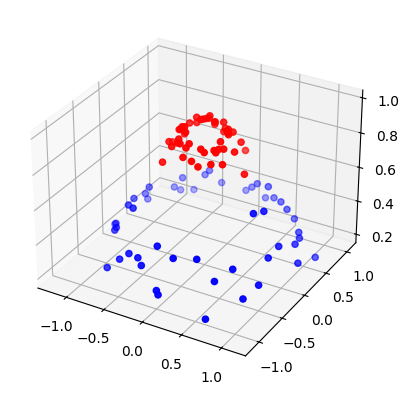

In [8]:
#plotting the data
ax = plt.subplot(projection = "3d")
ax.scatter3D(X[:,0],X[:,1],kernel_transformation(X),c=y,cmap = "bwr")

In [9]:
## training the data using linear and rbf
model1 = SVC(kernel="linear")
model1.fit(X,y)


SVC(kernel='linear')

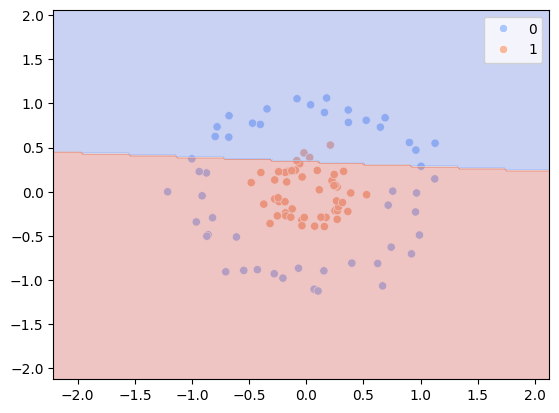

In [20]:
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y, palette='coolwarm')
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

fake_points = np.c_[xx.ravel(),yy.ravel()]
fake_point_prediction = model1.predict(fake_points)

fake_point_prediction=fake_point_prediction.reshape(xx.shape)
plt.contourf(xx,yy,fake_point_prediction,alpha=0.3, cmap='coolwarm')


In [17]:
print(xx)
print("*"*10)
print(xx.ravel())
print("*"*10)
print(fake_points)

[[-2.2134526  -2.19164284 -2.16983307 ...  2.08307085  2.10488061
   2.12669037]
 [-2.2134526  -2.19164284 -2.16983307 ...  2.08307085  2.10488061
   2.12669037]
 [-2.2134526  -2.19164284 -2.16983307 ...  2.08307085  2.10488061
   2.12669037]
 ...
 [-2.2134526  -2.19164284 -2.16983307 ...  2.08307085  2.10488061
   2.12669037]
 [-2.2134526  -2.19164284 -2.16983307 ...  2.08307085  2.10488061
   2.12669037]
 [-2.2134526  -2.19164284 -2.16983307 ...  2.08307085  2.10488061
   2.12669037]]
**********
[-2.2134526  -2.19164284 -2.16983307 ...  2.08307085  2.10488061
  2.12669037]
**********
[[-2.2134526  -2.12304775]
 [-2.19164284 -2.12304775]
 [-2.16983307 -2.12304775]
 ...
 [ 2.08307085  2.06196554]
 [ 2.10488061  2.06196554]
 [ 2.12669037  2.06196554]]


In [22]:
## training the data using linear and rbf
model2 = SVC(kernel="rbf")
model2.fit(X,y)


SVC()

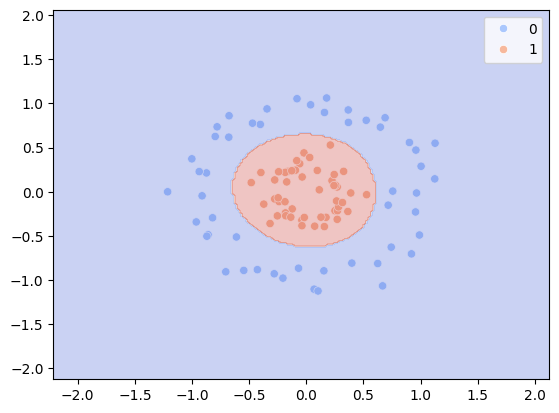

In [23]:
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y, palette='coolwarm')
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model2.predict(grid)
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')